# Auto encoders 
They are  Like GAN(Generative adversial Network) which will learn the input and output in a Unsupervised way

In [1]:
import torch
import torch.nn as nn
from torch.nn import functional as F

## Encoding Layer of Auto Encoder
- What it does is a Mystry but let me try to make a brief
    - if i have a big ball to play a game and i want to process the whole map at once (for that i need to become a pro,but i know i am not but lets continue)
    but its not possible so what I will do is I will make the map smaller(thats the reason games provide us a minimap) so let me be clear

**It Will change the big input to small thing so we can process it easily without more computaional cost**

In [2]:
class Encoder(nn.Module):
  def __init__(self):
    super().__init__()
    self.el1 = nn.Linear(28*28, 128)
    self.el2 = nn.Linear(128, 64)
    self.el3 = nn.Linear(64, 32)
    self.el4 = nn.Linear(32, 2)

  def forward(self,x):
    x = self.el1(x)
    x = F.relu(x)
    x = self.el2(x)
    x = F.relu(x)
    x = self.el3(x)
    x = F.relu(x)
    x = self.el4(x)
    return x

## Decoder Layer
It converts my small processing fat ass into actual size for getting the insights from it

In [3]:
class Decoder(nn.Module):
  def __init__(self):
    super().__init__()
    self.dl1 = nn.Linear(2, 32)
    self.dl2 = nn.Linear(32, 64)
    self.dl3 = nn.Linear(64, 128)
    self.dl4 = nn.Linear(128, 28*28)

  def forward(self, x):
    x = self.dl1(x)
    x = F.relu(x)
    x = self.dl2(x)
    x = F.relu(x)
    x = self.dl3(x)
    x = F.relu(x)
    x = self.dl4(x)
    return x

In [4]:
class Autoencoder(nn.Module):
  def __init__(self):
    super().__init__()
    self.encoder = Encoder()
    self.decoder = Decoder()

  def forward(self, x):
    encoded = self.encoder(x)
    decoded = self.decoder(encoded)
    return decoded

In [5]:
import torchvision.datasets as datasets
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
batch_size = 64
train_loader = torch.utils.data.DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset,batch_size=batch_size,shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 492kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.58MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.37MB/s]


In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = Autoencoder().to(device)

In [7]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [8]:
num_epochs = 50
model.train()
for epoch in range(num_epochs):
  for data in train_loader:
    img,_ = data
    img = img.view(img.size(0),-1).to(device)

    output = model(img)
    loss = criterion(output,img)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Streaming output truncated to the last 5000 lines.
Epoch [45/50], Loss: 0.1375
Epoch [45/50], Loss: 0.1362
Epoch [45/50], Loss: 0.1517
Epoch [45/50], Loss: 0.1366
Epoch [45/50], Loss: 0.1462
Epoch [45/50], Loss: 0.1424
Epoch [45/50], Loss: 0.1547
Epoch [45/50], Loss: 0.1480
Epoch [45/50], Loss: 0.1463
Epoch [45/50], Loss: 0.1518
Epoch [45/50], Loss: 0.1358
Epoch [45/50], Loss: 0.1356
Epoch [45/50], Loss: 0.1500
Epoch [45/50], Loss: 0.1511
Epoch [45/50], Loss: 0.1431
Epoch [45/50], Loss: 0.1369
Epoch [45/50], Loss: 0.1650
Epoch [45/50], Loss: 0.1389
Epoch [45/50], Loss: 0.1421
Epoch [45/50], Loss: 0.1513
Epoch [45/50], Loss: 0.1560
Epoch [45/50], Loss: 0.1380
Epoch [45/50], Loss: 0.1488
Epoch [45/50], Loss: 0.1284
Epoch [45/50], Loss: 0.1367
Epoch [45/50], Loss: 0.1403
Epoch [45/50], Loss: 0.1442
Epoch [45/50], Loss: 0.1396
Epoch [45/50], Loss: 0.1446
Epoch [45/50], Loss: 0.1544
Epoch [45/50], Loss: 0.1282
Epoch [45/50], Loss: 0.1289
Epoch [45/50], Loss: 0.1516
Epoch [45/50], Loss: 0.15

In [10]:
model.eval()
test_loss = 0.0
with torch.no_grad():
  for data in test_loader:
    img,ele=data
    img = img.view(img.size(0),-1).to(device)
    output = model(img)
    print((img,output))
    loss = criterion(output,img)
    test_loss += loss.item()

test_loss /= len(test_loader)

(tensor([[-1., -1., -1.,  ..., -1., -1., -1.],
        [-1., -1., -1.,  ..., -1., -1., -1.],
        [-1., -1., -1.,  ..., -1., -1., -1.],
        ...,
        [-1., -1., -1.,  ..., -1., -1., -1.],
        [-1., -1., -1.,  ..., -1., -1., -1.],
        [-1., -1., -1.,  ..., -1., -1., -1.]], device='cuda:0'), tensor([[-1.0017, -1.0016, -1.0031,  ..., -1.0031, -1.0016, -1.0008],
        [-1.0001, -1.0017, -1.0023,  ..., -1.0023, -1.0017, -0.9961],
        [-1.0016, -0.9982, -0.9957,  ..., -0.9958, -0.9985, -1.0006],
        ...,
        [-0.9942, -0.9967, -0.9973,  ..., -0.9973, -0.9966, -0.9885],
        [-1.0033, -0.9983, -0.9981,  ..., -0.9981, -0.9986, -1.0017],
        [-0.9893, -0.9942, -0.9981,  ..., -0.9980, -0.9938, -0.9828]],
       device='cuda:0'))
(tensor([[-1., -1., -1.,  ..., -1., -1., -1.],
        [-1., -1., -1.,  ..., -1., -1., -1.],
        [-1., -1., -1.,  ..., -1., -1., -1.],
        ...,
        [-1., -1., -1.,  ..., -1., -1., -1.],
        [-1., -1., -1.,  ..., -1.,

Testing it with actual and predicted and it was damn good

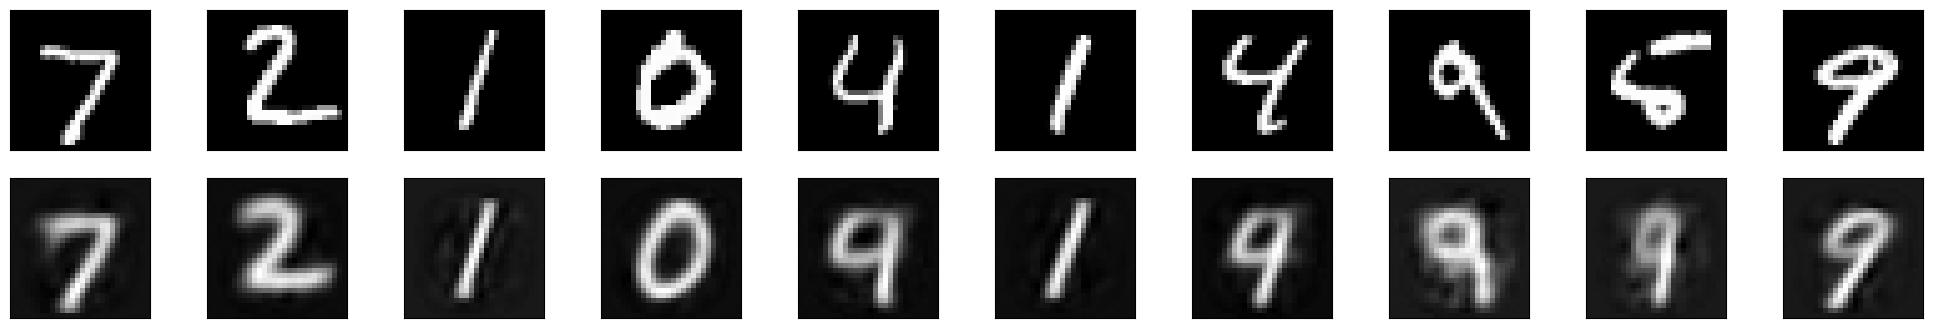

In [12]:
import matplotlib.pyplot as plt
import numpy as np

dataiter = iter(test_loader)
images, labels = next(dataiter)

images_flattened = images.view(images.size(0), -1).to(device)
output = model(images_flattened)

images_original = images.view(images.size(0), 1, 28, 28)
output_reshaped = output.view(output.size(0), 1, 28, 28).cpu()

images_original = images_original * 0.5 + 0.5
output_reshaped = output_reshaped * 0.5 + 0.5

fig, axes = plt.subplots(nrows=2, ncols=10, sharex=True, sharey=True, figsize=(25,4))
for images, row in zip([images_original, output_reshaped], axes):
    for img, ax in zip(images, row):
        ax.imshow(np.squeeze(img.detach().numpy()), cmap='gray')
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

plt.show()